In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_main = pd.read_csv("datasets/fact_bookings.csv")
df_date = pd.read_csv('datasets/dim_date.csv')
df_hotels = pd.read_csv('datasets/dim_hotels.csv')
df_rooms = pd.read_csv('datasets/dim_rooms.csv')
df_agg_bookings = pd.read_csv('datasets/fact_aggregated_bookings.csv')


In [4]:
df_main.sample(10)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
113072,Jul162216560RT27,16560,16-07-22,16-07-22,18-07-22,1.0,RT2,others,NaN,Checked Out,12600,12600
19581,May132219558RT117,19558,7/5/2022,13-05-22,14-05-22,3.0,RT1,direct online,5.0,Checked Out,10725,10725
112354,Jul152218561RT28,18561,11/7/2022,15-07-22,17-07-22,2.0,RT2,others,4.0,Checked Out,9000,9000
90422,Jul012218561RT25,18561,28-06-22,1/7/2022,2/7/2022,2.0,RT2,others,NaN,Checked Out,9000,9000
80081,Jun242219559RT212,19559,22-06-22,24-06-22,30-06-22,2.0,RT2,others,NaN,Cancelled,13500,5400
103800,Jul092219563RT311,19563,8/7/2022,9/7/2022,14-07-22,1.0,RT3,tripster,3.0,Checked Out,18000,18000
21195,May142218561RT312,18561,11/5/2022,14-05-22,20-05-22,2.0,RT3,others,5.0,Checked Out,12000,12000
6554,May052217559RT17,17559,29-04-22,5/5/2022,6/5/2022,2.0,RT1,direct online,5.0,Checked Out,11050,11050
60657,Jun112217560RT12,17560,11/6/2022,11/6/2022,12/6/2022,4.0,RT1,makeyourtrip,NaN,Cancelled,13260,5304
131316,Jul302216558RT23,16558,26-07-22,30-07-22,4/8/2022,1.0,RT2,others,4.0,Checked Out,12600,12600


In [5]:
# fixing date to consistent formats
df_main["booking_date"] = pd.to_datetime(df_main["booking_date"],format = "mixed")
df_main["check_in_date"] = pd.to_datetime(df_main["check_in_date"],format = "mixed")
df_main["checkout_date"] = pd.to_datetime(df_main["checkout_date"],format = "mixed")


In [6]:
# checking no of rows and columns
df_main.shape


(134590, 12)

In [7]:
# checking each rows and columns for null value and each column data type 
df_main.info()
#  leaving ratings as it is ! and checking on guests column

<class 'pandas.DataFrame'>
RangeIndex: 134590 entries, 0 to 134589
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   booking_id         134590 non-null  str           
 1   property_id        134590 non-null  int64         
 2   booking_date       134590 non-null  datetime64[us]
 3   check_in_date      134590 non-null  datetime64[us]
 4   checkout_date      134590 non-null  datetime64[us]
 5   no_guests          134587 non-null  float64       
 6   room_category      134590 non-null  str           
 7   booking_platform   134590 non-null  str           
 8   ratings_given      56683 non-null   float64       
 9   booking_status     134590 non-null  str           
 10  revenue_generated  134590 non-null  int64         
 11  revenue_realized   134590 non-null  int64         
dtypes: datetime64[us](3), float64(2), int64(3), str(4)
memory usage: 12.3 MB


In [8]:
#checking errors on guests count
df_main.no_guests[df_main.no_guests <0]

# cutting out these rows(since there are less rows)!
df_main = df_main[df_main.no_guests >=0]
df_main.shape #nearly 12 rows have been cutoff


(134578, 12)

In [9]:
#checking if nulls are same in whole column
df_main.ratings_given.unique()


array([nan,  5.,  4.,  3.,  1.,  2.])

                                              Moving on to clean other data sets

In [12]:
# cleaning data 
# fixing date to consistent formats
df_agg_bookings["check_in_date"] = pd.to_datetime(df_agg_bookings["check_in_date"],format = "mixed")

# checking for errors in booking and capacity:
df_agg_bookings[df_agg_bookings.successful_bookings > df_agg_bookings.capacity]
# cutoff the rows with such errors

df_agg_bookings_new = df_agg_bookings[df_agg_bookings.successful_bookings < df_agg_bookings.capacity] 
df_agg_bookings_new.sample(10)

,property_id,check_in_date,room_category,successful_bookings,capacity
7417,18558,2022-07-14,RT1,8,15.0
1861,18559,2022-05-19,RT3,8,23.0
6022,19561,2022-06-30,RT1,18,36.0
8393,16563,2022-07-23,RT4,12,18.0
8450,19563,2022-07-24,RT3,17,29.0
8257,16559,2022-07-22,RT3,20,32.0
1089,18562,2022-05-11,RT4,12,20.0
8875,17562,2022-07-28,RT4,2,6.0
2668,17559,2022-05-27,RT3,12,16.0
7454,17558,2022-07-14,RT3,15,27.0


In [15]:
# checking data ready for analysis
df_agg_bookings.sample(20)

,property_id,check_in_date,room_category,successful_bookings,capacity
6215,17559,2022-07-02,RT1,28,32.0
5396,16562,2022-06-23,RT4,3,6.0
3231,16561,2022-06-02,RT2,11,24.0
5125,19562,2022-06-21,RT2,11,23.0
8388,19562,2022-07-23,RT4,10,14.0
8026,17561,2022-07-20,RT2,21,36.0
3328,17558,2022-06-03,RT2,20,50.0
5301,18560,2022-06-23,RT1,15,30.0
8244,18558,2022-07-22,RT2,13,30.0
4682,19559,2022-06-16,RT4,1,3.0


In [16]:
# cleaning data 
df_date["date"] = pd.to_datetime(df_date["date"],format = "mixed")
df_date["day_type"] = df_date["day_type"].apply(lambda x :"weekday" if x == "weekeday" else x)



In [17]:
df_date.sample(10)

,date,mmm yy,week no,day_type
50,2022-06-20,Jun 22,W 26,weekday
37,2022-06-07,Jun 22,W 24,weekday
78,2022-07-18,Jul 22,W 30,weekday
82,2022-07-22,Jul 22,W 30,weekday
60,2022-06-30,Jun 22,W 27,weekday
30,2022-05-31,May 22,W 23,weekday
35,2022-06-05,Jun 22,W 24,weekend
55,2022-06-25,Jun 22,W 26,weekend
24,2022-05-25,May 22,W 22,weekday
17,2022-05-18,May 22,W 21,weekday


In [18]:
df_date.sample(20)

,date,mmm yy,week no,day_type
0,2022-05-01,May 22,W 19,weekend
91,2022-07-31,Jul 22,W 32,weekend
89,2022-07-29,Jul 22,W 31,weekday
4,2022-05-05,May 22,W 19,weekday
65,2022-07-05,Jul 22,W 28,weekday
52,2022-06-22,Jun 22,W 26,weekday
76,2022-07-16,Jul 22,W 29,weekend
12,2022-05-13,May 22,W 20,weekday
63,2022-07-03,Jul 22,W 28,weekend
66,2022-07-06,Jul 22,W 28,weekday


                                                  1. REVENUE ANALYSIS 


In [19]:
# total revenue generated :
print("Total Revenue Generated :",df_main["revenue_generated"].sum())

# total revenue generated :
print("Total Revenue Realized :",df_main["revenue_realized"].sum())

Total Revenue Generated : 2069545455
Total Revenue Realized : 1708603879


                                                Revenue by city

In [20]:
# Merging:
main_with_city = pd.merge(df_main,df_hotels,on = "property_id")

# checking with main df shape to verify if duplicates :
main_with_city.shape

# checking null sum for verification :
main_with_city.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77899
booking_status           0
revenue_generated        0
revenue_realized         0
property_name            0
category                 0
city                     0
dtype: int64

In [21]:
Rev_by_city = main_with_city.groupby("city")["revenue_realized"].sum().sort_values(ascending = False)
Rev_by_city

city
Mumbai       668602231
Bangalore    420383550
Hyderabad    325179310
Delhi        294438788
Name: revenue_realized, dtype: int64

<Axes: xlabel='city'>

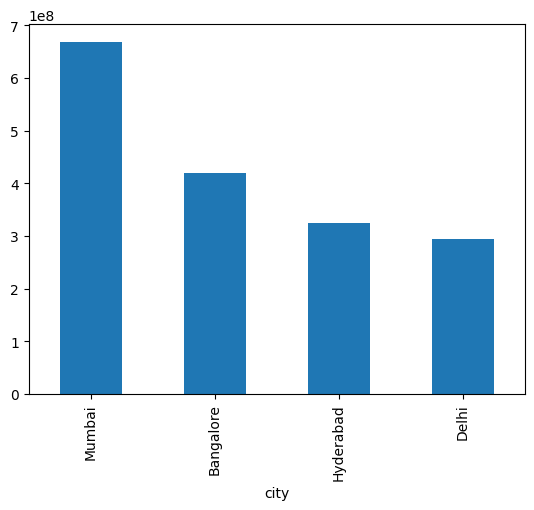

In [23]:
Rev_by_city.plot(kind="bar")

Insight: Mumbai and Bangalore drives the most business 

                                                            Revenue by Hotel

In [24]:
Rev_by_hotel = main_with_city.groupby("property_name")["revenue_realized"].sum().sort_values(ascending = False)
Rev_by_hotel 

property_name
Atliq Exotica    320291568
Atliq Palace     304081863
Atliq City       285798439
Atliq Blu        260851922
Atliq Bay        260022118
Atliq Grands     211471234
Atliq Seasons     66086735
Name: revenue_realized, dtype: int64

<Axes: xlabel='Revenue', ylabel='property_name'>

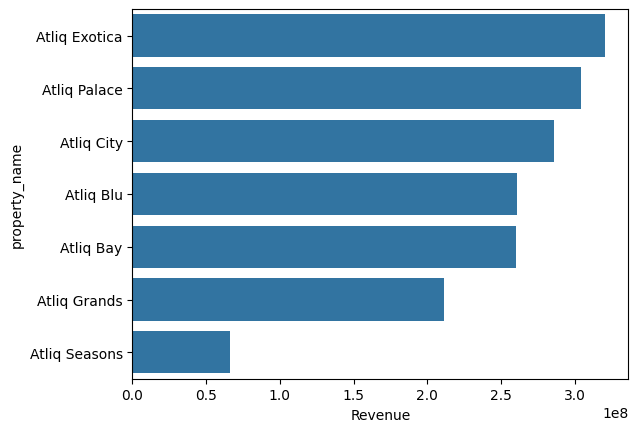

In [54]:
rev_df = Rev_by_hotel.reset_index() 
rev_df.columns = ["property_name","Revenue"]
# Bar plotting using Seaborn:

sns.barplot(data = rev_df,x="Revenue",y = "property_name")


                                                         Revenue by Room category

In [30]:
Rev_by_Rcategory = main_with_city.groupby("category")["revenue_realized"].sum().sort_values(ascending = False)
Rev_by_Rcategory 

category
Luxury      1052636842
Business     655967037
Name: revenue_realized, dtype: int64

<Axes: xlabel='category'>

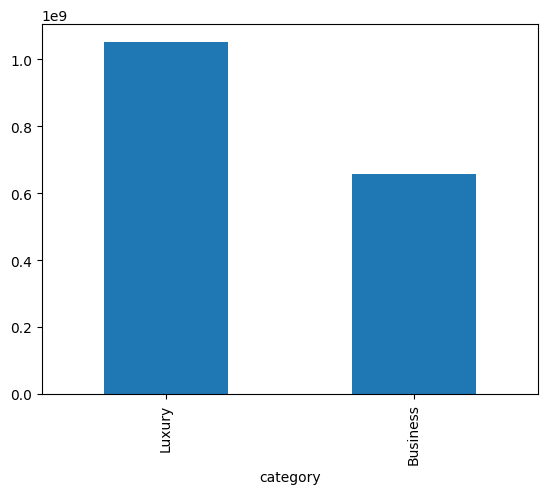

In [83]:
Rev_by_Rcategory.plot(kind="bar",x="Revenue")

                                                          2. OCCUPANCY ANALYSIS 





                                           * Occupancy rate = bookings / capacity


In [58]:

df_agg_bookings["Occupancy_Rate"] = (df_agg_bookings.successful_bookings / df_agg_bookings.capacity)

occ_rate =df_agg_bookings.groupby("room_category")["Occupancy_Rate"].mean().sort_values(ascending = False)

occ_by_room = pd.merge(occ_rate,df_rooms, left_on ="room_category",right_on = "room_id")
occ_by_room

,Occupancy_Rate,room_id,room_class
0,0.593002,RT4,Presidential
1,0.582242,RT1,Standard
2,0.580402,RT2,Elite
3,0.580283,RT3,Premium


                                            * Which hotels are underperforming?


In [64]:
hotels = pd.merge(df_agg_bookings,df_hotels,on = "property_id")

hotel_perfm =hotels.groupby("property_name")["Occupancy_Rate"].mean().sort_values(ascending = False)
hotel_perfm

property_name
Atliq Blu        0.631230
Atliq Palace     0.599437
Atliq City       0.599057
Atliq Exotica    0.579049
Atliq Bay        0.578746
Atliq Grands     0.551135
Atliq Seasons    0.445064
Name: Occupancy_Rate, dtype: float64

                                            * Weekday vs weekend occupancy

In [143]:
week_enq = pd.merge(hotels,df_date, left_on = "check_in_date",right_on = "date")
week_enq.groupby("day_type")["Occupancy_Rate"].mean().sort_values(ascending = False)

day_type
weekend    0.742410
weekday    0.518223
Name: Occupancy_Rate, dtype: float64

                                                  3. CUSTOMER BEHAVIOR 




                                                       Cancellation rate


In [144]:
cancel_rate = (df_main.booking_status == 'Cancelled').mean()*100
print("Cancellation Rate :",cancel_rate)

Cancellation Rate : 24.83095305324793


In [145]:
cancelled = df_main[df_main.booking_status == 'Cancelled']
cancelled.shape

(33417, 12)

                                                     Booking platforms performance

In [81]:
by_platform = df_main.groupby("booking_platform")["booking_id"].count().sort_values(ascending=False)
by_platform

booking_platform
others            55062
makeyourtrip      26896
logtrip           14754
direct online     13376
tripster           9630
journey            8106
direct offline     6754
Name: booking_id, dtype: int64

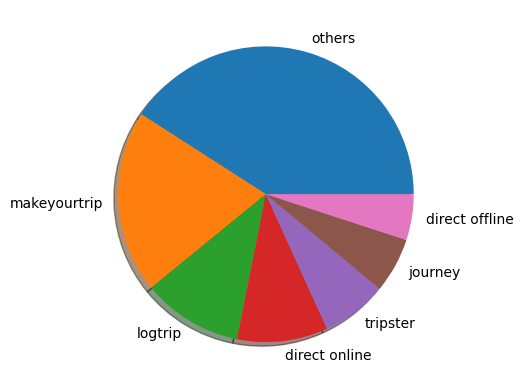

In [82]:
by_platform =by_platform.reset_index()
by_platform.columns = ["booking_platform","bookings"]
plt.pie(by_platform["bookings"],labels = by_platform["booking_platform"], shadow = True)
plt.show()